In [44]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]=T[1] # Left boundary
    T[-1]=T[-2]**2/max(T[-3],1e-40) # Right boundary

def solve_two_layer_FTCS(k1, k2, z_dis,Pda,Lz,nz,tf,device):
    # Construct numerical grid
    dz = Lz/nz; z = torch.arange(-0.5, nz+1, device=device)*dz
    # Finite volume, *** z_dis is at a cell boundary ***
    # need one more point at each end, *** size of z = (nz+2) ***

    # Make sure we reach tf in integer number of setps
    dt = 0.5*(dz**2)/max(k1, k2) # need to include k1 and k2 in dt
    nt = int(np.ceil(tf/dt)); dt = tf/nt # need to uopdate dt 
    print(f'nz = {nz}, nt = {nt}; alignment of nt*dt with tf: err = {nt*dt-tf}')
    
    # Find index m such that z[m+1] > z_dis
    m = torch.searchsorted(z, z_dis, right=True).item()-1
    # no need to move a scalar between gpu and cpu?
    # check z[m+1/2]=z_dis?
    print(f'alignment of cell boundary with z_dis: err = {z[m]+0.5*dz-z_dis}')
    
    # Harmonic mean of k at z_dis
    k_interface = 2 * k1 * k2 / (k1 + k2)
    # Precompute kh (effective k at half grid point z_{j+1/2})
    kh = torch.where(z[:-1] < z_dis, k1, k2); kh[m] = k_interface
    # *** size of kh = (nz+1) ***
    # Pytorch will automatically use the device and dtype of z
    
    # Source at internal points, *** size of source = nz ***
    source = Pda * torch.exp(-z[1:-1])

    # Need to pre-allocate T and J
    T = torch.zeros(nz+2, device=device) # size of T = nz+2
    Jh = torch.zeros(nz+1, device=device) # size of k = nz+1
    
    # advance in time steps
    for tstep in range(nt):
        # FTCS update
        set_BCs(T) # start each step by enforcing BCs
        Jh = -kh * (T[1:]-T[:-1])/dz # Flux 
        T[1:-1] = T[1:-1] + dt/dz*(Jh[:-1] - Jh[1:])+dt*source
    set_BCs(T) # at the end enforce BC again
    
    # Map T to Th (T at half grid points z_{j+1/2}); This mapping is nevessary 
    # because coarse grid and fine grid do not share any common cell centers!!!
    zh = 0.5*(z[:-1]+z[1:])
    Th = 0.5*(T[:-1]+T[1:]); Th[m]=T[m]+0.5*(T[m+1]-T[m])*k_interface/k1
    return z, T, zh, Th

In [45]:
# Generate the data

device='cpu'
k1=1.0; k2=2.0; z_dis=1.0; Pda=1.0; tf=2; 
Lz=4.0; nz_unit=10; nz1=int(Lz)*nz_unit;
z1,T1,zh1,Th1 = solve_two_layer_FTCS(k1,k2,z_dis,Pda,Lz,nz1,tf,device)
nz2=nz1*2;


nz = 40, nt = 800; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0


In [46]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

kernel = RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8,optimizer=None)

# Generate 

gp.fit(zh1.reshape(-1, 1), Th1.reshape(-1, 1))
print("GP trained.")


GP trained.


In [59]:

z2,T2,zh2,Th2 = solve_two_layer_FTCS(1,2,z_dis,Pda,Lz,nz2,tf,device) 

mean_pred, std_pred = gp.predict(zh2.reshape(-1, 1), return_std=True)

print("GP Mean:", mean_pred[0])
print("GP Std:", std_pred[0])


nz = 80, nt = 3200; alignment of nt*dt with tf: err = 0.0
alignment of cell boundary with z_dis: err = 0.0
GP Mean: 0.8457742513785895
GP Std: 9.759454976024059e-05


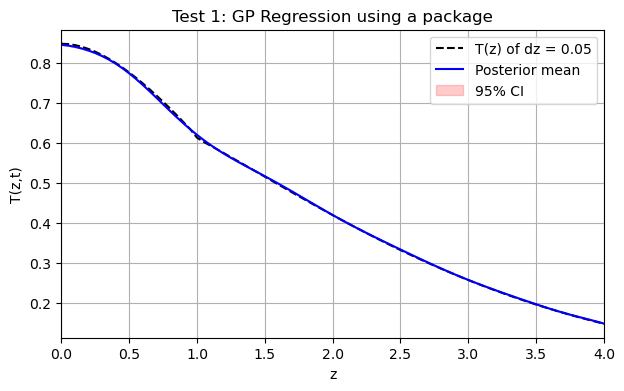

In [60]:
plt.figure(figsize=(7,4))
plt.plot(zh2.cpu(), Th2.cpu(), 'k--', label=f'T(z) of dz = {Lz/nz2}')
plt.plot(zh2.cpu(), mean_pred, 'b-', label="Posterior mean")
plt.fill_between(zh2.cpu().ravel(),
                 mean_pred - 2*std_pred,
                 mean_pred + 2*std_pred,
                 color='r', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(0,4); 
plt.title("Test 1: GP Regression using a package")
plt.xlabel("z"); plt.ylabel("T(z,t)"); plt.grid(True)

In [61]:
error = abs(mean_pred - Th2.cpu().numpy() )
error.shape

(81,)

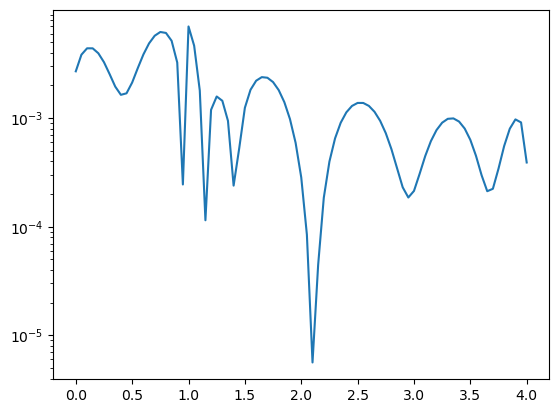

In [62]:
plt.semilogy(zh2.cpu(),error)